# Notebook 2 — CatBoost Recursive Walk-Forward Forecasting
## One Model, Recursively Applied 96 Times

**Learning Goals for This Notebook**
- Understand the *recursive walk-forward* multi-step forecasting strategy
- See why a single t+1 model, applied repeatedly, produces a complete multi-step forecast
- Implement a feature reconstruction function that rebuilds the feature vector from rolling buffers at each prediction step
- Compare the walk-forward approach directly with the direct multi-output approach from Notebook 1

---

### The Recursive Walk-Forward Strategy

In Notebook 1, we trained **96 separate models** — one per horizon. Here we take the opposite approach: train **one model** to predict the *next* value (t+1), then reuse it 96 times.

At each recursive step h:
1. Use the model to predict `ŷ(t+h+1)` from the current feature vector
2. Append `ŷ(t+h+1)` to the rolling buffers (as if it were the real value)
3. Reconstruct the feature vector for step h+1 using those updated buffers
4. Repeat until we have 96 predictions

### The Core Challenge: Feature Reconstruction

In Step 1 (h=0), we can use the precomputed features from `df_test` directly — they are based on real historical values.

For steps h=1…95, the features include lag values, rolling means, and differencing that reference *predicted* values we just generated. We cannot use `df_test` anymore — we must rebuild the feature vector on-the-fly from rolling buffers updated with our own predictions.

The `build_feature_row()` function in Step 8 handles this exactly.

### Strategy Comparison

| | Direct Multi-Output (NB1) | Recursive Walk-Forward (this notebook) |
|---|---|---|
| **# Models** | 96 independent models | 1 single model |
| **Error Propagation** | None — each model predicts its horizon directly | Accumulates — prediction errors feed into later steps |
| **Train / Test Split** | 2015–2017 / 2018 | 2015–2017 / 2018 (identical) |
| **Memory (storage)** | 96 model files | 1 model file |
| **Inference** | Parallel (96 independent predictions per row) | Sequential (96 steps per origin) |

---

## Step 1 — Import Libraries

Same library stack as Notebook 1. The only noteworthy addition is that we need `numpy` arrays for the rolling buffer arithmetic inside `build_feature_row()`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from typing import List, Union, Optional
from catboost import CatBoostRegressor
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2 — Load Data

Same two datasets as Notebook 1:
- **`energy_data.csv`** — Hourly Spanish electricity data (2015–2018)
- **`weather_data.csv`** — Hourly weather observations

> Using the same raw data as Notebook 1 ensures a fair comparison — any difference in results comes purely from the forecasting strategy, not the data.

In [2]:
# Load CSVs
df_energy = pd.read_csv('Data/energy_data.csv')
df_weather = pd.read_csv('Data/weather_data.csv')

print(f"Energy data shape: {df_energy.shape}")
print(f"Weather data shape: {df_weather.shape}")

Energy data shape: (35064, 17)
Weather data shape: (35064, 12)


## Step 3 — Data Preprocessing

Identical pipeline to Notebook 1: parse timestamps → join energy + weather on datetime index → resample to hourly frequency → forward-fill gaps → keep only `total load actual`.

Keeping the preprocessing identical to Notebook 1 is important: we want to ensure both strategies operate on exactly the same cleaned series.

In [3]:
# Parse and index timestamps
df_weather['dt_iso'] = pd.to_datetime(df_weather['dt_iso'], utc=True, errors='coerce')
df_weather.set_index('dt_iso', inplace=True)

df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True, errors='coerce')
df_energy.set_index('time', inplace=True)

# Join on datetime index
df = df_energy.join(df_weather, how='inner')
df.index = pd.to_datetime(df.index, utc=True)

# Resample to consistent hourly frequency and forward-fill gaps
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(full_index)
df = df.ffill()

# Focus on the target column only
df = df[['total load actual']]

print(f"Combined dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Combined dataset shape: (35064, 1)
Date range: 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Missing values: 0


## Step 4 — Exploratory Visualization

Same time series plot as Notebook 1. Revisit it here to confirm the data is identical and to remind yourself of the seasonal and daily patterns before we build the model.

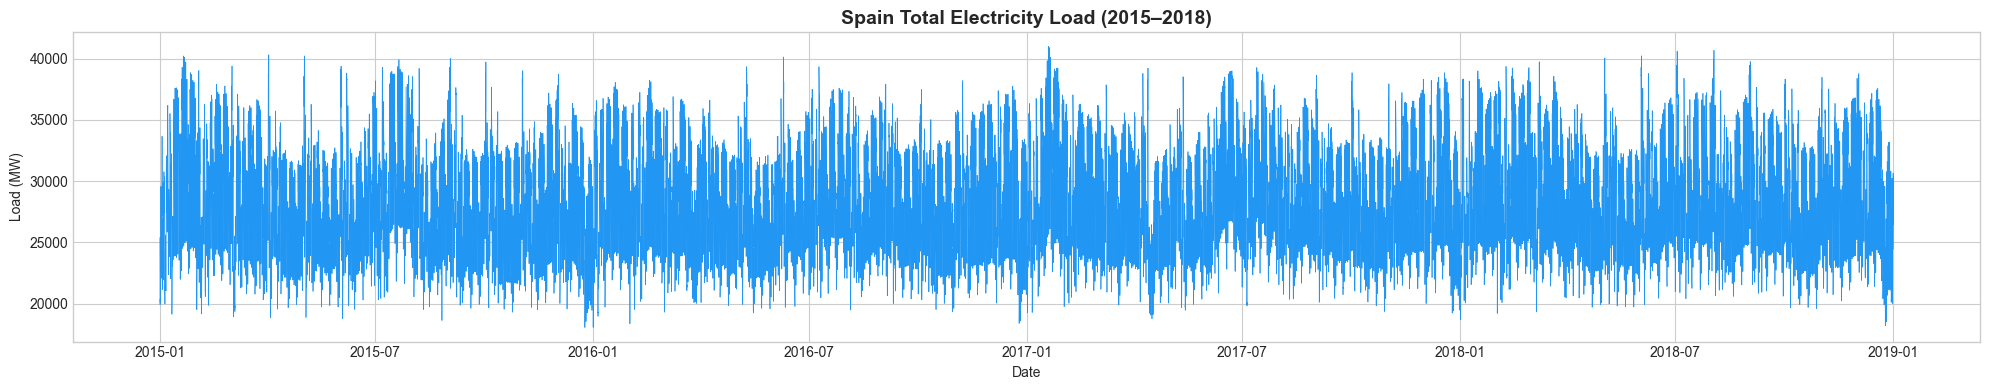

In [4]:
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df.index, df['total load actual'], linewidth=0.5, color='#2196F3')
ax.set_title('Spain Total Electricity Load (2015\u20132018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

## Step 5 — Feature Engineering

**Identical feature engineering pipeline to Notebook 1** — calendar features, cyclical encoding, lag features, rolling statistics, and differencing.

We keep this step identical so that the model in this notebook sees exactly the same feature space as each of the 96 models in Notebook 1. Any difference in forecast accuracy is then entirely attributable to the strategy (direct vs. recursive), not the features.

Refer back to the Notebook 1 feature engineering section for the full explanation of each feature category.

In [5]:
# --- Step 5a: Extract Calendar Features ---
target_columns = ['total load actual']

df['time'] = df.index
df['time'] = pd.to_datetime(df['time'], utc=True)

df['hr'] = df['time'].dt.hour.values
df['mnth'] = df['time'].dt.month.values
df['weekday'] = df['time'].dt.weekday.values
df['week'] = df['time'].dt.isocalendar().week.values
df['day'] = df['time'].dt.day.values

df.drop(columns=['time'], inplace=True)

print(f"After calendar features: {df.shape[1]} columns")

After calendar features: 6 columns


In [6]:
# --- Step 5b: Lag Features, Rolling Statistics, Differencing, and Cyclical Encoding ---

df.loc[:, 'previous_' + target_columns[0]] = df[target_columns[0]]

all_col = df.columns.tolist()
all_col.remove('total load actual')

for feature in all_col:
    # --- Previous load features (lag, rolling MA, rolling std, differencing) ---
    if feature == 'previous_' + target_columns[0]:
        # Rolling Moving Averages (smoothed trend at multiple scales)
        for w in [1, 3, 6, 12, 24, 48, 72]:
            df[feature + f'_ma{w}'] = df[feature].rolling(window=w).mean()
        for i in range(4, 7):
            df[feature + f'_ma{24*i}'] = df[feature].rolling(window=24*i).mean()

        # Lag features (past values at specific offsets)
        for s in [1, 3, 6, 12, 24, 48, 72]:
            df[feature + f'_{s}'] = df[feature].shift(s)
        for i in range(4, 7):
            df[feature + f'_{24*i}'] = df[feature].shift(24*i)

        # Rolling Standard Deviation (volatility signals)
        for w, label in [(12, '12'), (24, '24'), (24*7, '7d'), (24*30, '30d')]:
            df[feature + f'_std_{label}'] = df[feature].rolling(window=w).std()

        # Differencing (rate of change)
        for d in [1, 3, 6, 12, 24, 48, 72]:
            df[feature + f'_diff_{d}'] = df[feature].diff(d)
        for i in range(4, 7):
            df[feature + f'_diff_{24*i}'] = df[feature].diff(24*i)

    # --- Hour features (cyclical + lag + rolling) ---
    if feature == 'hr':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 24)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 24)
        for w in [1, 3, 6, 12, 18]:
            df[feature + f'_ma{w}'] = df[feature].rolling(window=w).mean()
        for s in [1, 3, 6, 12, 18]:
            df[feature + f'_{s}'] = df[feature].shift(s)

    # --- Day features (cyclical + lag + rolling) ---
    if feature == 'day':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 31)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 31)
        for w in [24, 48, 72, 96]:
            df[feature + f'_ma{w}'] = df[feature].rolling(window=w).mean()
        for s in [24, 48, 72, 96]:
            df[feature + f'_{s}'] = df[feature].shift(s)

    # --- Month, Weekday, Week: cyclical encoding only ---
    if feature == 'mnth':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 12)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 12)
    if feature == 'weekday':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 7)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 7)
    if feature == 'week':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 52)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 52)

print(f"Total features after engineering: {df.shape[1]} columns")
print(f"Total samples: {df.shape[0]:,} rows")

Total features after engineering: 69 columns
Total samples: 35,064 rows


In [7]:
# Preview the engineered feature matrix
print("Feature columns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:3d}. {col}")

print(f"\nSample row (last available):")
display(df.tail(1).T)

Feature columns:
    1. total load actual
    2. hr
    3. mnth
    4. weekday
    5. week
    6. day
    7. previous_total load actual
    8. hr_sin
    9. hr_cos
   10. hr_ma1
   11. hr_ma3
   12. hr_ma6
   13. hr_ma12
   14. hr_ma18
   15. hr_1
   16. hr_3
   17. hr_6
   18. hr_12
   19. hr_18
   20. mnth_sin
   21. mnth_cos
   22. weekday_sin
   23. weekday_cos
   24. week_sin
   25. week_cos
   26. day_sin
   27. day_cos
   28. day_ma24
   29. day_ma48
   30. day_ma72
   31. day_ma96
   32. day_24
   33. day_48
   34. day_72
   35. day_96
   36. previous_total load actual_ma1
   37. previous_total load actual_ma3
   38. previous_total load actual_ma6
   39. previous_total load actual_ma12
   40. previous_total load actual_ma24
   41. previous_total load actual_ma48
   42. previous_total load actual_ma72
   43. previous_total load actual_ma96
   44. previous_total load actual_ma120
   45. previous_total load actual_ma144
   46. previous_total load actual_1
   47. previous_total loa

,2018-12-31 22:00:00+00:00
total load actual,24455.0
hr,22
mnth,12
weekday,0
week,1
...,...
previous_total load actual_diff_48,-2877.0
previous_total load actual_diff_72,-3560.0
previous_total load actual_diff_96,-3427.0
previous_total load actual_diff_120,-2653.0


## Step 6 — Chronological Train / Test Split

**Identical split to Notebook 1** to ensure a fair comparison:
- **Training set**: 2015-01-01 → 2017-10-28 (~2.8 years)
- **Test set**: 2018-01-01 → end (~1 year)

The same deliberate gap between training end and test start applies here too, for the same leakage-prevention reasons described in Notebook 1.

In [8]:
# Chronological split — no leakage (identical to Notebook 4)
df_train = df.loc['2015-01-01':'2017-10-28 00:00:00'].copy()
df_test = df.loc['2018-01-01':].copy()

# Drop rows with NaN (from rolling/lag features at the start of training)
df_train.dropna(inplace=True)

# Define feature columns (everything except the target)
features = df.columns.tolist()
features.remove('total load actual')

print(f"Training set: {df_train.shape[0]:,} rows ({df_train.index.min().date()} to {df_train.index.max().date()})")
print(f"Test set:     {df_test.shape[0]:,} rows ({df_test.index.min().date()} to {df_test.index.max().date()})")
print(f"Features:     {len(features)}")
print(f"Target:       total load actual")

Training set: 24,027 rows (2015-01-30 to 2017-10-28)
Test set:     8,759 rows (2018-01-01 to 2018-12-31)
Features:     68
Target:       total load actual


## Step 7 — Train a Single CatBoost Model (t+1 Only)

We train **one** CatBoost model: features at time t → target at time t+1.

This is the same as Notebook 1's first model (horizon k=1), trained on the same data.

Why the same shift-by-1 construction? We want the model to predict "what will the load be one hour from now?" At inference time, we repeatedly ask this question 96 times, each time using the *previous prediction* as part of the context.

> **Design choice:** We could instead train on a sliding window of different horizons (multi-task learning) or use the full range of shifts. But the simplest and most common walk-forward baseline is: train one t+1 predictor and apply it recursively. That is what we do here.

In [9]:
# Train single t+1 model (identical to NB4 model #1)
X_train = df_train.iloc[:-1][features]
y_train = df_train.iloc[1:]['total load actual']

model = CatBoostRegressor(verbose=0, random_state=42)
model.fit(X_train, y_train)

print(f"Model trained on {len(X_train):,} samples")
print(f"Features: {len(features)}")
print(f"Target: total load actual (t+1)")

Model trained on 24,026 samples
Features: 68
Target: total load actual (t+1)


## Step 8 — Recursive Feature Reconstruction

This is the key technical challenge of the walk-forward strategy.

### The problem

At step h=0 (predict t+1), the feature vector is simply the precomputed row from `df_test` — all features use real historical values.

At step h=1 (predict t+2), some features must reference `ŷ(t+1)` — a predicted value we just made. We can no longer use the static `df_test` row; we must rebuild the feature vector using a rolling buffer that contains our prediction in place of the true value.

At step h=2, features reference both `ŷ(t+1)` and `ŷ(t+2)` (our two most recent predictions), and so on.

### The solution: rolling buffers

`build_feature_row()` maintains three rolling buffers:
- `load_buffer`: recent load values (actual history + accumulated predictions), length ≥ 721 (to support 30-day rolling std)
- `hr_buffer`: recent hour-of-day values
- `day_buffer`: recent day-of-month values

At each step h, it reads from these buffers using the same offsets as the original feature engineering pipeline (lags, rolling windows, differences), ensuring the model sees exactly the same feature structure it was trained on.

> **Why this matters:** The model's prediction quality depends on the features being consistent with training. If we fed raw scalars in the wrong positions or used different window sizes, the model would receive out-of-distribution input and produce nonsensical predictions.

In [10]:
def build_feature_row(load_buffer, hr_buffer, day_buffer, timestamp, features_order):
    """
    Build a feature vector for one recursive prediction step.

    Parameters:
        load_buffer: list of recent load values (actual + predicted), most recent last. Min 721 elements.
        hr_buffer:   list of recent hour values, min 19 elements.
        day_buffer:  list of recent day values, min 97 elements.
        timestamp:   pd.Timestamp for the current step.
        features_order: list of feature names in the exact training order.

    Returns:
        np.ndarray of shape (n_features,) matching features_order.
    """
    row = {}

    # ── Calendar features ──
    hr = timestamp.hour
    mnth = timestamp.month
    wd = timestamp.weekday()
    wk = timestamp.isocalendar()[1]
    dy = timestamp.day

    row['hr'] = hr
    row['mnth'] = mnth
    row['weekday'] = wd
    row['week'] = wk
    row['day'] = dy

    # ── previous_total load actual = current load (last in buffer) ──
    row['previous_total load actual'] = load_buffer[-1]

    # Rolling Moving Averages
    for w in [1, 3, 6, 12, 24, 48, 72]:
        row[f'previous_total load actual_ma{w}'] = np.mean(load_buffer[-w:])
    for i in range(4, 7):
        w = 24 * i
        row[f'previous_total load actual_ma{w}'] = np.mean(load_buffer[-w:])

    # Lag features
    for s in [1, 3, 6, 12, 24, 48, 72]:
        row[f'previous_total load actual_{s}'] = load_buffer[-1 - s]
    for i in range(4, 7):
        s = 24 * i
        row[f'previous_total load actual_{s}'] = load_buffer[-1 - s]

    # Rolling Standard Deviation
    for w, label in [(12, '12'), (24, '24'), (24*7, '7d'), (24*30, '30d')]:
        row[f'previous_total load actual_std_{label}'] = np.std(load_buffer[-w:], ddof=1)

    # Differencing
    for d in [1, 3, 6, 12, 24, 48, 72]:
        row[f'previous_total load actual_diff_{d}'] = load_buffer[-1] - load_buffer[-1 - d]
    for i in range(4, 7):
        d = 24 * i
        row[f'previous_total load actual_diff_{d}'] = load_buffer[-1] - load_buffer[-1 - d]

    # ── Hour features ──
    row['hr_sin'] = np.sin(2 * np.pi * hr / 24)
    row['hr_cos'] = np.cos(2 * np.pi * hr / 24)
    for w in [1, 3, 6, 12, 18]:
        row[f'hr_ma{w}'] = np.mean(hr_buffer[-w:])
    for s in [1, 3, 6, 12, 18]:
        row[f'hr_{s}'] = hr_buffer[-1 - s]

    # ── Day features ──
    row['day_sin'] = np.sin(2 * np.pi * dy / 31)
    row['day_cos'] = np.cos(2 * np.pi * dy / 31)
    for w in [24, 48, 72, 96]:
        row[f'day_ma{w}'] = np.mean(day_buffer[-w:])
    for s in [24, 48, 72, 96]:
        row[f'day_{s}'] = day_buffer[-1 - s]

    # ── Cyclical encodings for mnth, weekday, week ──
    row['mnth_sin'] = np.sin(2 * np.pi * mnth / 12)
    row['mnth_cos'] = np.cos(2 * np.pi * mnth / 12)
    row['weekday_sin'] = np.sin(2 * np.pi * wd / 7)
    row['weekday_cos'] = np.cos(2 * np.pi * wd / 7)
    row['week_sin'] = np.sin(2 * np.pi * wk / 52)
    row['week_cos'] = np.cos(2 * np.pi * wk / 52)

    return np.array([row[f] for f in features_order])

print("build_feature_row() defined.")

build_feature_row() defined.


## Step 9 — Recursive Walk-Forward Prediction Loop

### What happens in the loop

For each test origin timestamp `t`:

1. **h=0 (first step):** Use the precomputed feature row from `df_test`. This is exact — all features come from real observed values. Predict `ŷ(t+1)`.

2. **h=1…95 (recursive steps):** 
   - Append the latest prediction to `load_buffer`
   - Advance the timestamp by one hour
   - Call `build_feature_row()` to reconstruct the feature vector from the updated buffers
   - Predict the next value

3. Collect the 96 predictions and 96 actual values for this origin.

### Error accumulation in practice

At h=0, the prediction error is the irreducible single-step error. At h=1, we feed our potentially imperfect `ŷ(t+1)` into the model as if it were the true `y(t+1)`. Any error in step h propagates into step h+1 and beyond. Over 96 steps, small per-step errors can amplify noticeably.

This is the fundamental limitation of recursive walk-forward — and why the per-horizon MAE curve for this notebook typically shows a steeper upward slope than Notebook 1's direct approach.

In [11]:
FORECAST_HORIZON = 96
BUFFER_SIZE = 750  # > 720 needed for 30-day rolling std

feature_name = 'total load actual'

# Precompute arrays for fast buffer initialization
load_series = df[feature_name].values
all_hours = np.array([ts.hour for ts in df.index])
all_days = np.array([ts.day for ts in df.index])

# Global index where test set starts
test_start_global = df.index.get_loc(df_test.index[0])

# Precomputed test features for h=0 (direct from DataFrame — no reconstruction needed)
X_test_all = df_test[features].values

# Walk-Forward recursive prediction
forecast_rows = []

for origin_local in tqdm(range(len(df_test) - FORECAST_HORIZON), desc="Walk-Forward (recursive 96-step)"):
    origin_global = test_start_global + origin_local
    origin_time = df.index[origin_global]

    # Initialize buffers with actual historical data up to the origin
    buf_start = origin_global - BUFFER_SIZE + 1
    load_buffer = list(load_series[buf_start:origin_global + 1])
    hr_buffer = list(all_hours[max(0, origin_global - 100):origin_global + 1])
    day_buffer = list(all_days[max(0, origin_global - 100):origin_global + 1])

    preds_96 = []

    for h in range(FORECAST_HORIZON):
        if h == 0:
            # Use precomputed features (exact match with training pipeline)
            x = X_test_all[origin_local].reshape(1, -1)
        else:
            # Build features recursively from buffers
            current_time = origin_time + pd.Timedelta(hours=h)
            x = build_feature_row(load_buffer, hr_buffer, day_buffer, current_time, features).reshape(1, -1)

        pred = float(model.predict(x)[0])
        preds_96.append(pred)

        # Update buffers with the prediction for the next recursive step
        load_buffer.append(pred)
        next_time = origin_time + pd.Timedelta(hours=h + 1)
        hr_buffer.append(next_time.hour)
        day_buffer.append(next_time.day)

    # Collect actual values for this forecast window
    actuals_96 = [float(load_series[origin_global + 1 + h]) for h in range(FORECAST_HORIZON)]

    forecast_rows.append([origin_time, preds_96, actuals_96])

print(f"\nGenerated {len(forecast_rows):,} forecast windows, each with {FORECAST_HORIZON} recursive steps")

Walk-Forward (recursive 96-step):   0%|          | 0/8663 [00:00<?, ?it/s]


Generated 8,663 forecast windows, each with 96 recursive steps


## Step 10 — Build Forecast DataFrame

Same format as Notebook 1 — one row per origin timestamp, with prediction and actual lists of length 96. This consistent schema makes cross-notebook comparison straightforward.

In [12]:
# Same format as Notebook 4 for easy comparison
forecast_df = pd.DataFrame(
    forecast_rows,
    columns=['time', feature_name + '_prediction', feature_name]
)
forecast_df.reset_index(drop=True, inplace=True)

print(f"Forecast DataFrame shape: {forecast_df.shape}")
print(f"Each row contains {FORECAST_HORIZON}-step predictions and actuals")
display(forecast_df.head())

Forecast DataFrame shape: (8663, 3)
Each row contains 96-step predictions and actuals


,time,total load actual_prediction,total load actual
0,2018-01-01 00:00:00+00:00,"[21169.55954331053, 20700.504956346776, 20548....","[20589.0, 19547.0, 18871.0, 18688.0, 18869.0, ..."
1,2018-01-01 01:00:00+00:00,"[19973.651156637687, 19849.642600872736, 20058...","[19547.0, 18871.0, 18688.0, 18869.0, 19263.0, ..."
2,2018-01-01 02:00:00+00:00,"[19368.06544080825, 19457.23791321081, 19628.2...","[18871.0, 18688.0, 18869.0, 19263.0, 19046.0, ..."
3,2018-01-01 03:00:00+00:00,"[19061.352619669153, 19555.92175592381, 20044....","[18688.0, 18869.0, 19263.0, 19046.0, 19563.0, ..."
4,2018-01-01 04:00:00+00:00,"[19199.837534819548, 19739.648059885105, 19953...","[18869.0, 19263.0, 19046.0, 19563.0, 21063.0, ..."


## Step 11 — Evaluation Metrics

Same metrics as Notebook 1: overall MAE / RMSE averaged across all horizons and windows, plus per-horizon MAE plotted across all 96 steps.

**What to watch for when comparing with Notebook 1:**
- Is the overall MAE higher or lower here than the direct approach? Why?
- Does the per-horizon MAE curve slope more steeply upward here? This would confirm that recursive error accumulation is real.
- At which horizon does the performance gap between direct and recursive become significant?

In [13]:
def compute_metrics(actual_col, prediction_col, label="CatBoost"):
    """
    Compute MSE, RMSE, MAE both as overall averages and per-horizon.
    
    Parameters:
        actual_col: Series of lists (actual values per forecast window)
        prediction_col: Series of lists (predicted values per forecast window)
        label: Name for the results column
    
    Returns:
        avg_metrics: DataFrame with overall MSE, RMSE, MAE
        horizon_metrics: DataFrame with per-horizon MSE, RMSE, MAE
    """
    a = np.asarray(actual_col.tolist())
    p = np.asarray(prediction_col.tolist())

    mask = ~np.any(np.isnan(a), axis=1) & ~np.any(np.isnan(p), axis=1)

    mse = np.mean(np.square(a[mask, :] - p[mask, :]))
    mae = np.mean(np.abs(a[mask, :] - p[mask, :]))

    mse_t = np.mean(np.square(a[mask, :] - p[mask, :]), axis=0)
    mae_t = np.mean(np.abs(a[mask, :] - p[mask, :]), axis=0)

    avg_metrics = pd.DataFrame({
        label: {
            "Mean Squared Error (MSE)": f"{mse:,.1f}",
            "Root Mean Squared Error (RMSE)": f"{np.sqrt(mse):,.1f}",
            "Mean Absolute Error (MAE)": f"{mae:,.1f}",
        }
    })

    horizon_metrics = pd.DataFrame({
        "horizon_hour": np.arange(1, len(mse_t) + 1),
        "mse": mse_t,
        "rmse": np.sqrt(mse_t),
        "mae": mae_t,
    })

    return avg_metrics, horizon_metrics

In [14]:
avg_metrics, horizon_metrics = compute_metrics(
    forecast_df[feature_name],
    forecast_df[feature_name + '_prediction'],
    label="CatBoost"
)

print("=" * 50)
print("OVERALL METRICS (averaged across all horizons)")
print("=" * 50)
display(avg_metrics)

OVERALL METRICS (averaged across all horizons)


,CatBoost
Mean Squared Error (MSE),"6,142,191.0"
Root Mean Squared Error (RMSE),"2,478.3"
Mean Absolute Error (MAE),"1,757.7"


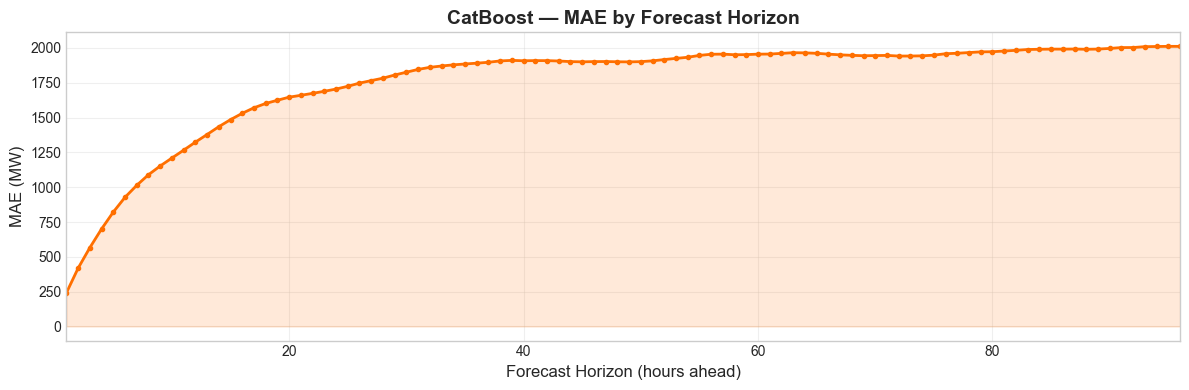

MAE at t+1:  242.1 MW
MAE at t+24: 1,704.9 MW
MAE at t+48: 1,900.9 MW
MAE at t+96: 2,011.7 MW


In [15]:
# Plot MAE by forecast horizon — shows how error grows with prediction distance
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(horizon_metrics['horizon_hour'], horizon_metrics['mae'], 
        color='#FF6F00', linewidth=2, marker='o', markersize=3)
ax.fill_between(horizon_metrics['horizon_hour'], 0, horizon_metrics['mae'], 
                alpha=0.15, color='#FF6F00')
ax.set_xlabel('Forecast Horizon (hours ahead)', fontsize=12)
ax.set_ylabel('MAE (MW)', fontsize=12)
ax.set_title('CatBoost — MAE by Forecast Horizon', fontsize=14, fontweight='bold')
ax.set_xlim(1, FORECAST_HORIZON)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MAE at t+1:  {horizon_metrics['mae'].iloc[0]:,.1f} MW")
print(f"MAE at t+24: {horizon_metrics['mae'].iloc[23]:,.1f} MW")
print(f"MAE at t+48: {horizon_metrics['mae'].iloc[47]:,.1f} MW")
print(f"MAE at t+96: {horizon_metrics['mae'].iloc[95]:,.1f} MW")

## Step 12 — Forecast Visualization

Same three test windows as Notebook 1 (indices 200, 400, 600) so you can directly compare the predicted curves.

**What to look for vs. Notebook 1:**
- Do the first ~12 hours look similar between both notebooks (since early recursive steps use mostly real historical features)?
- Does the forecast diverge from actuals more noticeably at the 48–96 hour range?
- Are there windows where the recursive approach "drifts" upward or downward into a trend that doesn't materialise?

In [16]:
def create_timestamps(last_timestamp, freq, periods=1):
    """Generate `periods` timestamps after `last_timestamp` at a given frequency."""
    return pd.date_range(
        start=last_timestamp, freq=freq, periods=periods + 1
    ).tolist()[1:]

In [17]:
def plot_predictions(
    df, predictions_df, freq, timestamp_column, channel, indices, plot_context=None
):
    """
    Plot forecast windows alongside actual values.
    
    Parameters:
        df: DataFrame with actual values and a timestamp column
        predictions_df: DataFrame with 'time', prediction lists, and actual lists
        freq: Frequency string (e.g., 'h' for hourly)
        timestamp_column: Name of the timestamp column in df
        channel: Target column name
        indices: List of row indices from predictions_df to plot
        plot_context: Number of historical points to show before forecast
    """
    pred_col = f"{channel}_prediction"
    predictions_subset = [predictions_df.iloc[i] for i in indices]

    gt_df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(gt_df[timestamp_column]):
        gt_df[timestamp_column] = pd.to_datetime(gt_df[timestamp_column])
    gt_df = gt_df.set_index(timestamp_column)

    prediction_length = len(predictions_subset[0][pred_col])
    if plot_context is None:
        plot_context = 2 * prediction_length

    fig, axs = plt.subplots(len(indices), 1, figsize=(14, 3 * len(indices)), squeeze=False)
    axs = axs.flatten()

    for i, idx in enumerate(indices):
        row = predictions_subset[i]
        origin = pd.to_datetime(row[timestamp_column])
        if gt_df.index.tz is not None and origin.tzinfo is None:
            origin = origin.tz_localize(gt_df.index.tz)
        elif gt_df.index.tz is None and origin.tzinfo is not None:
            origin = origin.tz_localize(None)

        if origin not in gt_df.index:
            axs[i].set_title(f"Window {idx} — origin not found")
            continue

        loc = gt_df.index.get_loc(origin)
        ctx_start = max(0, loc - plot_context + 1)

        ts_ctx = gt_df.index[ctx_start:loc + 1]
        y_ctx = gt_df.iloc[ctx_start:loc + 1][channel].values

        act_end = min(loc + 1 + prediction_length, len(gt_df))
        ts_act = gt_df.index[loc + 1:act_end]
        y_act = gt_df.iloc[loc + 1:act_end][channel].values

        ts_pred = create_timestamps(origin, freq=freq, periods=prediction_length)
        y_pred = row[pred_col]

        # Plot
        ts_full = ts_ctx.append(ts_act) if len(ts_act) > 0 else ts_ctx
        y_full = np.concatenate([y_ctx, y_act])

        axs[i].plot(ts_full, y_full, label="Actual", color='#2196F3', linewidth=1.5)
        axs[i].plot(ts_pred[:len(y_pred)], y_pred, label="Predicted", 
                    color='#FF6F00', linewidth=1.5, linestyle='--')
        axs[i].axvline(x=origin, color='red', linestyle='-', alpha=0.7, label='Forecast Origin')
        axs[i].set_title(f"Forecast Window {idx} — Origin: {origin}", fontsize=11)
        axs[i].legend(loc='upper right', fontsize=8)
        axs[i].set_ylabel('Load (MW)')

    plt.tight_layout()
    plt.show()

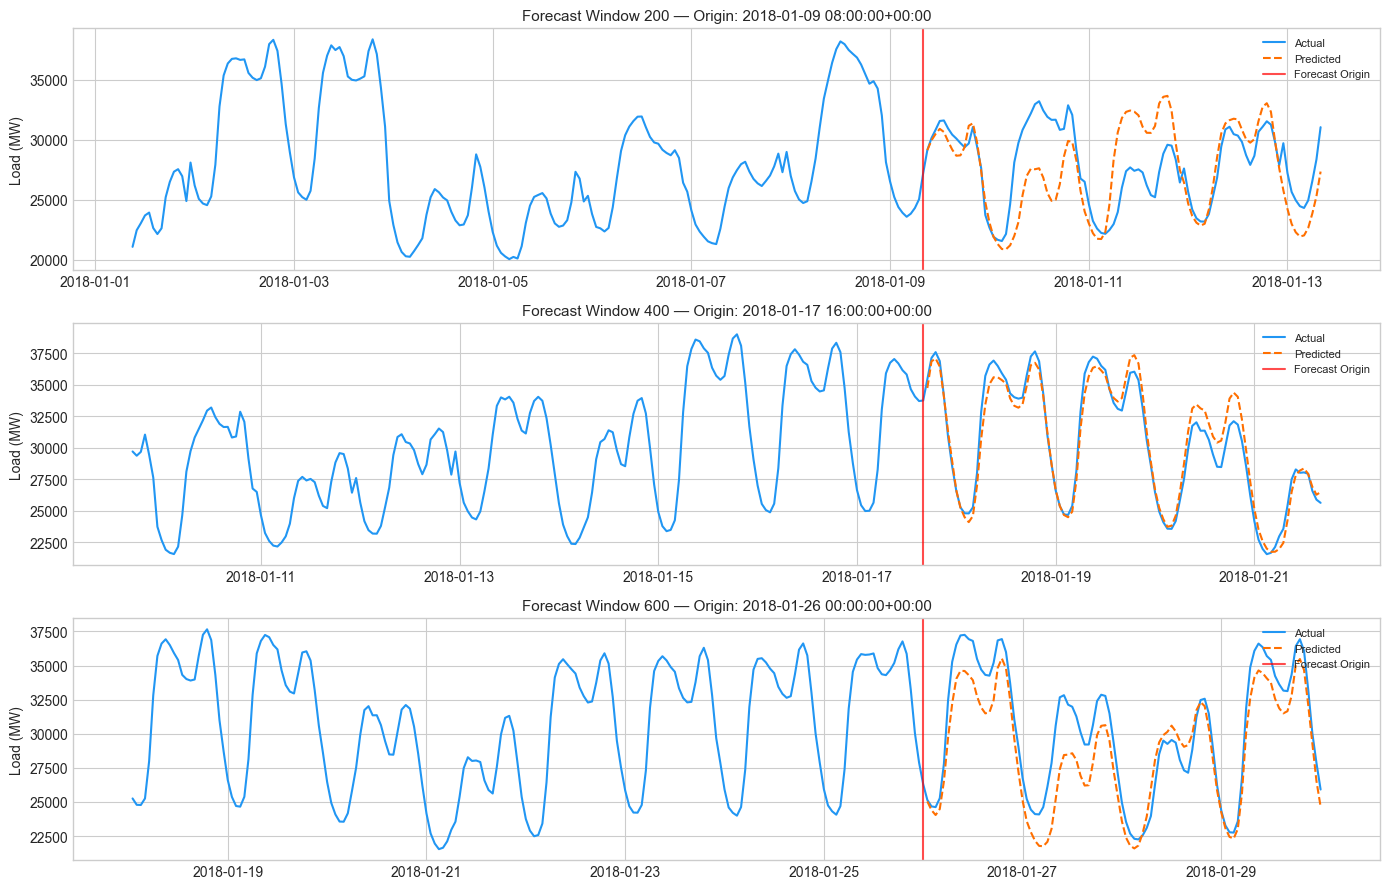

In [18]:
# Prepare test data for plotting
df_test_plot = df_test.copy().reset_index()
df_test_plot.rename(columns={'index': 'time'}, inplace=True)

# Plot 3 example forecast windows
plot_predictions(
    df=df_test_plot,
    predictions_df=forecast_df,
    freq="h",
    timestamp_column="time",
    channel=feature_name,
    indices=[200, 400, 600],
)

## Step 13 — Save Results

Same output format as Notebook 1. We save `forecast_df` to a pickle file for later cross-notebook comparison.

In [19]:
import pickle

output_path = 'catboost_walkforward_forecast.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(forecast_df, f)

print(f"Forecast saved to {output_path}")
print(f"Shape: {forecast_df.shape}")

Forecast saved to catboost_walkforward_forecast.pkl
Shape: (8663, 3)


## Summary & Key Takeaways

### What we built
1. Loaded and preprocessed the same 4-year Spanish electricity dataset as Notebook 1
2. Applied the identical 70+ feature engineering pipeline
3. Trained a **single** CatBoost model for one-step-ahead (t+1) prediction
4. Implemented a recursive walk-forward loop with on-the-fly feature reconstruction from rolling buffers
5. Evaluated 96-step forecasts on the same 2018 test year — allowing direct comparison with Notebook 1

### Walk-Forward vs. Direct: What Did We Learn?

| Aspect | Direct (NB1) | Recursive Walk-Forward (this notebook) |
|---|---|---|
| Models to train | 96 | 1 |
| Training time | 96× | 1× |
| Error accumulation | None | Compounds over recursive steps |
| Long-horizon accuracy | Generally better | Degrades — errors build up |
| Implementation complexity | Simple (loop over horizons) | Requires feature reconstruction at each step |

### The fundamental trade-off

A single model is far cheaper to train and maintain. The cost is error propagation over the recursive steps — each misprediction becomes part of the context for the next step. For short horizons (< ~12 h), the difference is often small. For long horizons (> 48 h), the direct strategy typically wins.

### Discussion questions
1. At what horizon does the walk-forward MAE surpass the direct MAE? Is the crossover point earlier or later than you expected?
2. `build_feature_row()` uses predicted values in the lag and rolling buffers. What would happen if the single model's random errors cancelled out over 96 steps vs. systematically biased in one direction?
3. Could you combine both strategies — use direct models for the first 24 hours, then switch to recursive walk-forward? What would that look like?

---
*Notebook 2 of 3 — Continue to `TTM_Granite_Zeroshot.ipynb` (Notebook 3) to see how a pre-trained foundation model forecasts with zero training and zero feature engineering.*